## Seaborn Mastery: The Complete Data Visualization Training Notebook

# 1. Imports & Environment Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

# set a professional, consistent visual theme for the whole notebook
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams['figure.dpi']= 100
print("Libraries imported successfully")
print("Seaborn version:", sns.__version__)
print("Pandas version:", pd.__version__)

Libraries imported successfully
Seaborn version: 0.13.2
Pandas version: 2.3.1


# 2. Dataset Loading

In [2]:

# Load the dataset
df = sns.load_dataset("tips")

# Alternative if you have a local file:
# df = pd.read_csv("tips.csv")

df

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


# 3. Data Understanding

In [3]:
# 3.1 df.head() - peek at the first rows
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [4]:
# 3.2 df.info() - structural summary
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [5]:
# 3.3 df.shape() - dimensions
df.shape

(244, 7)

In [6]:
# 3.4 df.columns - Columns name
df.columns

Index(['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size'], dtype='object')

In [7]:
# 3.5 df.dtypes - Data type only
df.dtypes

total_bill     float64
tip            float64
sex           category
smoker        category
day           category
time          category
size             int64
dtype: object

In [8]:
# 3.6 df.describe() - Statistical summary
df.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


In [9]:
# 3.7 df.isnull().sum() - Missing value check
df.isnull().sum()

total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64

In [10]:
# 3.8 df.duplicated().sum() - Duplicate Row Check
df.duplicated().sum()

np.int64(1)

In [11]:
# 3.9 .value_counts() - Frequency of categories
df['day'].value_counts()

day
Sat     87
Sun     76
Thur    62
Fri     19
Name: count, dtype: int64

In [12]:
# 3.10 .unique() - List distinct values
df['day'].unique()

['Sun', 'Sat', 'Thur', 'Fri']
Categories (4, object): ['Thur', 'Fri', 'Sat', 'Sun']

In [13]:
# 3.11 .nunique() - Count of Distinct Values
for col in df.columns:
    print(f"{col:12s} -> {df[col].nunique()} unique values")

total_bill   -> 229 unique values
tip          -> 123 unique values
sex          -> 2 unique values
smoker       -> 2 unique values
day          -> 4 unique values
time         -> 2 unique values
size         -> 6 unique values


## 4 EDA Concepts - The Theroy Before The Charts

## 5 Histogram - sns.histplot() / sns.displot()

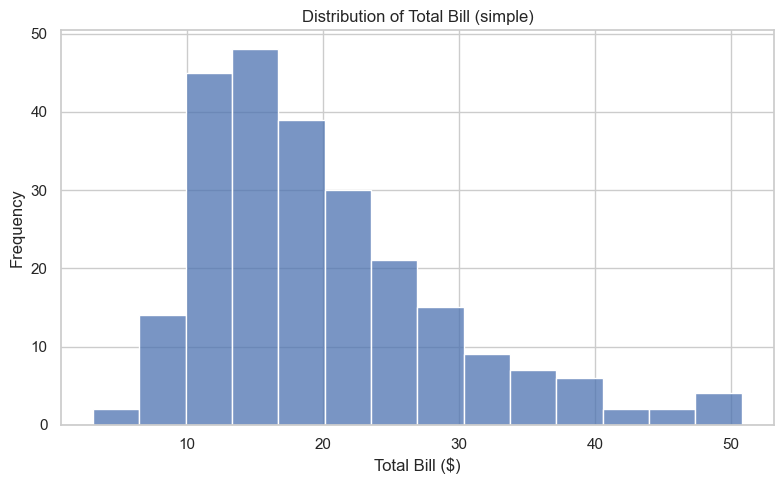

In [14]:
plt.figure(figsize=(8,5))
sns.histplot(df['total_bill'])
plt.title('Distribution of Total Bill (simple)')
plt.xlabel('Total Bill ($)')
plt.ylabel('Frequency')
plt.grid(True)
plt.tight_layout()
plt.show()

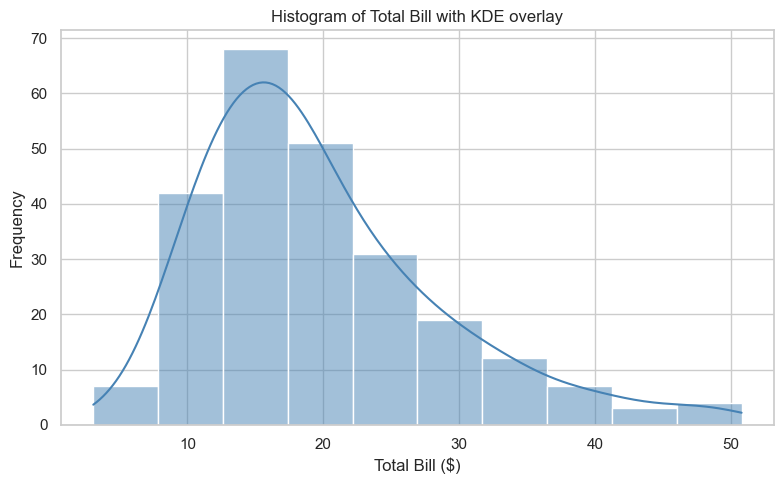

In [15]:
plt.figure(figsize=(8,5))
sns.histplot(df['total_bill'], bins=10, kde=True, color= 'steelblue')
plt.title('Histogram of Total Bill with KDE overlay')
plt.xlabel('Total Bill ($)')
plt.ylabel('Frequency')
plt.grid(True)
plt.tight_layout()
plt.show()

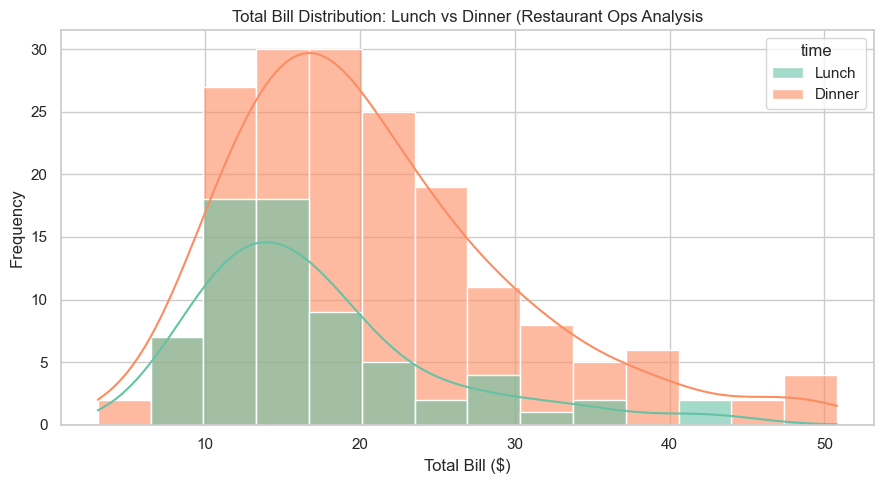

In [16]:
plt.figure(figsize=(9,5))
sns.histplot(data=df, x= 'total_bill', hue= 'time', kde=True, 
             multiple= 'layer', palette= 'Set2', alpha=0.6)
plt.title('Total Bill Distribution: Lunch vs Dinner (Restaurant Ops Analysis')
plt.xlabel('Total Bill ($)')
plt.ylabel('Frequency')
plt.grid(True)
plt.tight_layout()
plt.show()

## 6 Box Plot - sns.boxplot()

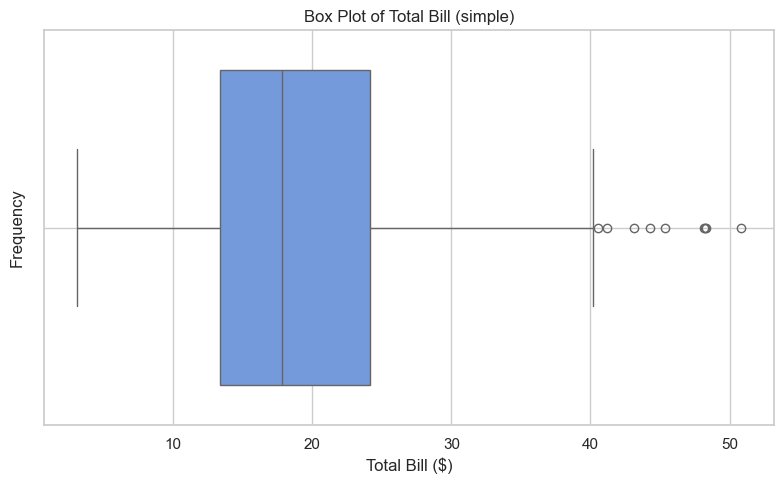

In [17]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['total_bill'], color= 'cornflowerblue')
plt.title('Box Plot of Total Bill (simple)')
plt.xlabel('Total Bill ($)')
plt.ylabel('Frequency')
plt.grid(True)
plt.tight_layout()
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_20040\2055005048.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='day', y= 'total_bill', palette= 'Set2')


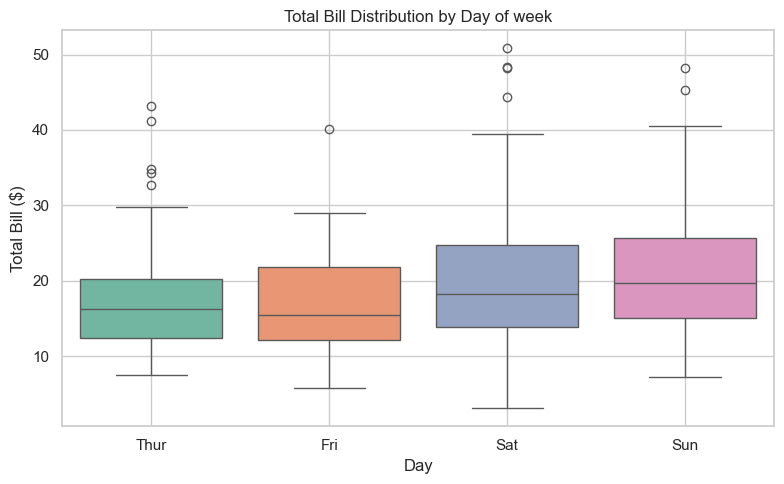

In [18]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='day', y= 'total_bill', palette= 'Set2')
plt.title('Total Bill Distribution by Day of week')
plt.xlabel('Day')
plt.ylabel('Total Bill ($)')
plt.grid(True)
plt.tight_layout()
plt.show()

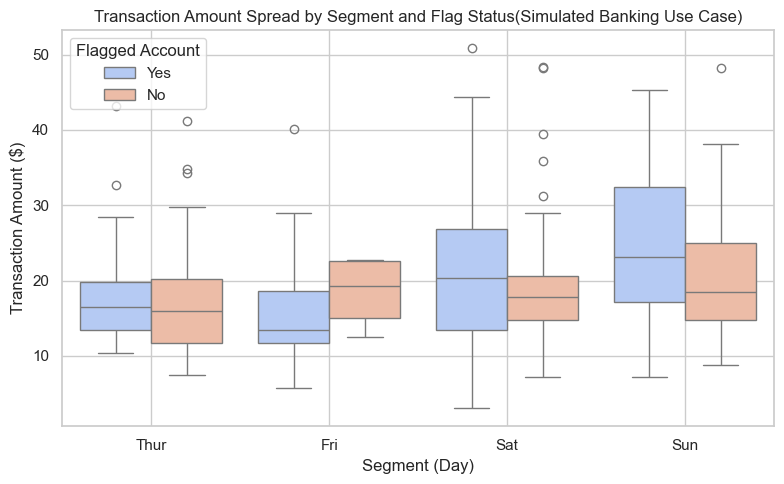

In [19]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='day', y= 'total_bill', hue='smoker', palette='coolwarm', dodge=True)
plt.title('Transaction Amount Spread by Segment and Flag Status(Simulated Banking Use Case)' )
plt.xlabel('Segment (Day)')
plt.ylabel('Transaction Amount ($)')
plt.legend(title='Flagged Account')
plt.grid(True)
plt.tight_layout()
plt.show()

## 7 Scatter Plot - sns.scatterplot()

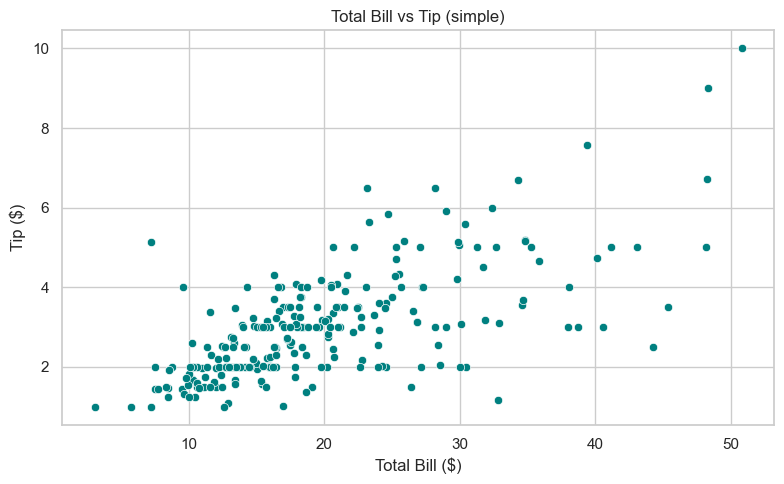

In [20]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df['total_bill'], y=df['tip'], color='teal')
plt.title('Total Bill vs Tip (simple)')
plt.xlabel('Total Bill ($)')
plt.ylabel('Tip ($)')
plt.grid(True)
plt.tight_layout()
plt.show()

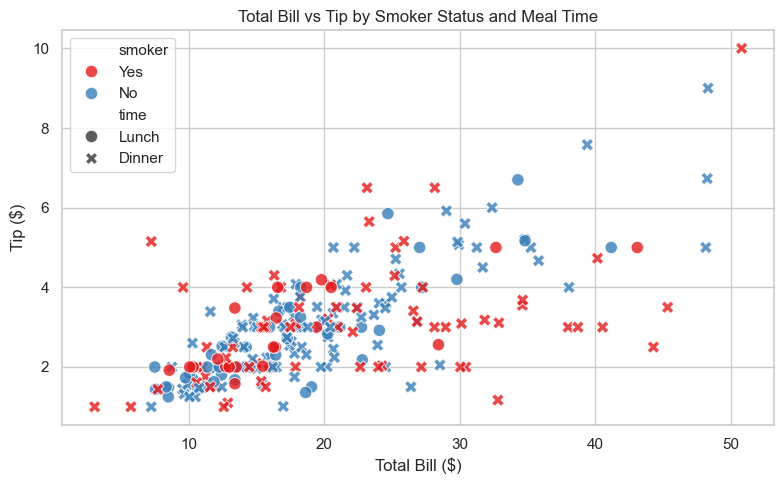

In [21]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='total_bill', y= 'tip', hue='smoker', 
style='time', 
                palette='Set1', alpha=0.8, s=80)
plt.title('Total Bill vs Tip by Smoker Status and Meal Time')
plt.xlabel('Total Bill ($)')
plt.ylabel('Tip ($)')
plt.grid(True)
plt.tight_layout()
plt.show()

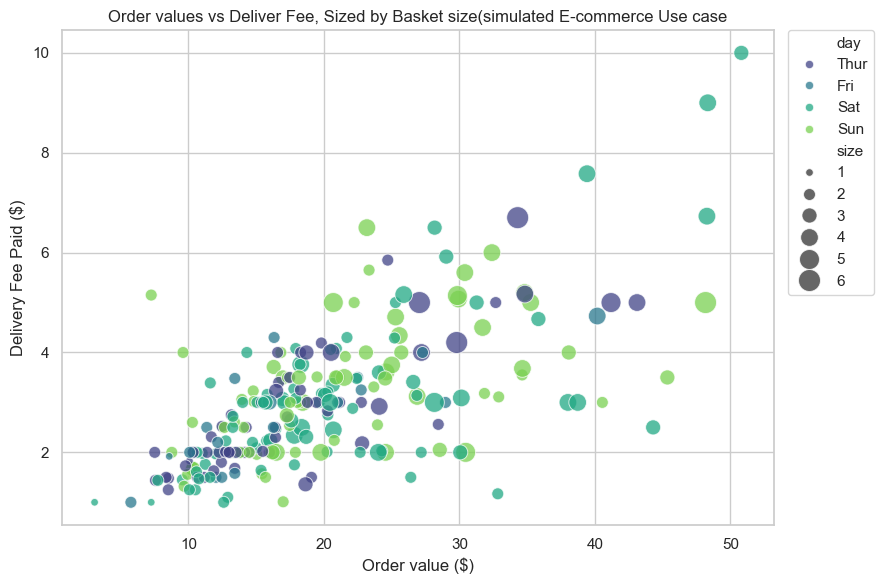

In [22]:
plt.figure(figsize=(9,6))
sns.scatterplot(data=df, x='total_bill', y= 'tip', hue='day', size='size',
                sizes=(30,250), palette='viridis', alpha=0.75)
                
plt.title('Order values vs Deliver Fee, Sized by Basket size(simulated E-commerce Use case')
plt.xlabel('Order value ($)')
plt.ylabel('Delivery Fee Paid ($)')
plt.legend(bbox_to_anchor=(1.02,1), loc='upper left', borderaxespad=0)
plt.grid(True)
plt.tight_layout()
plt.show()

## 8 Relplot - sns.relplot()

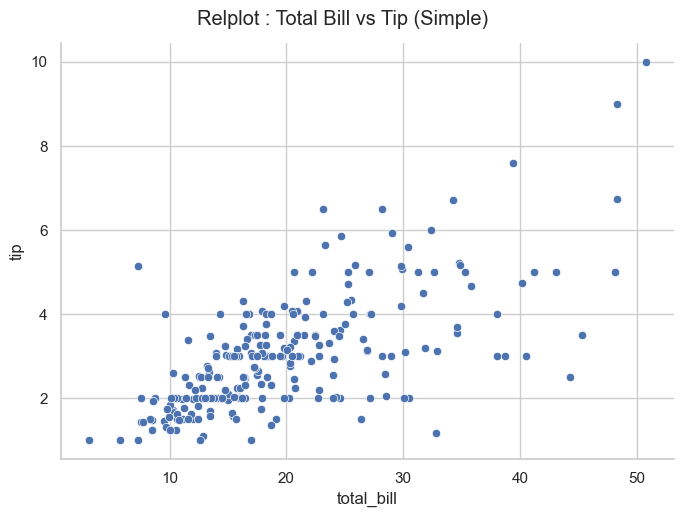

In [23]:

sns.relplot(data=df, x='total_bill', y= 'tip', height=5, aspect=1.4) 
plt.suptitle('Relplot : Total Bill vs Tip (Simple)', y=1.03)
plt.show()

<Figure size 800x500 with 0 Axes>

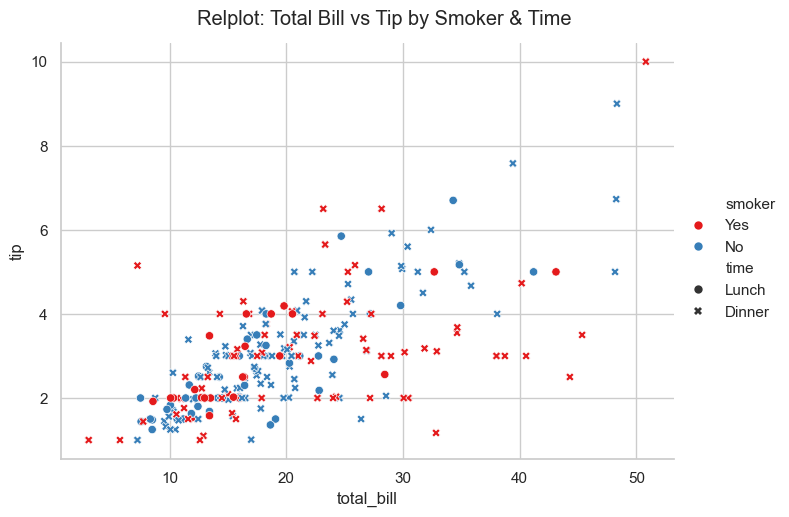

In [24]:
plt.figure(figsize=(8,5))
sns.relplot(data=df, x='total_bill', y= 'tip', hue='smoker', style='time', 
                palette='Set1', height=5, aspect=1.4)
plt.suptitle('Relplot: Total Bill vs Tip by Smoker & Time', y=1.03)

plt.show()

<Figure size 800x500 with 0 Axes>

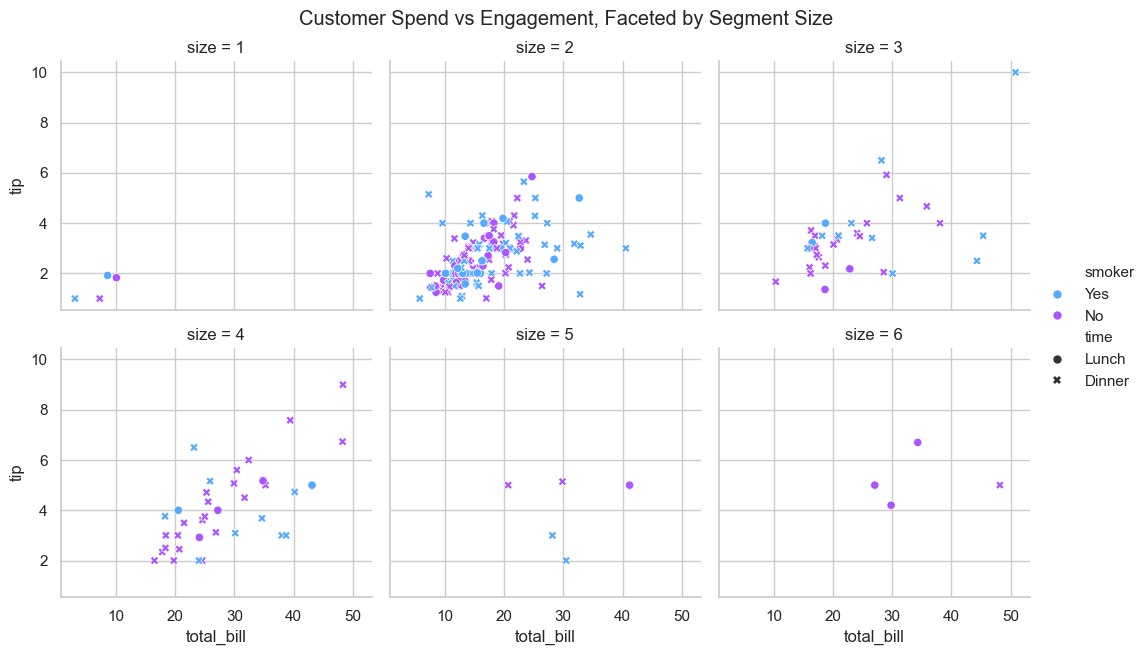

In [25]:
plt.figure(figsize=(8,5))
sns.relplot(data=df, x='total_bill', y= 'tip', hue='smoker', style='time', 
            col='size', col_wrap=3, palette='cool', height=3.2, aspect=1.1)
plt.suptitle('Customer Spend vs Engagement, Faceted by Segment Size', y=1.02)

plt.show()

## 9 Line Plot - sns.lineplot()

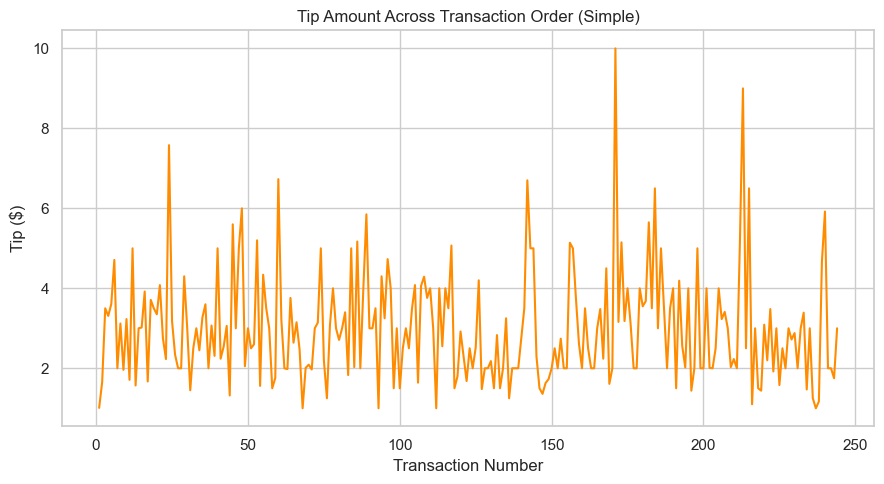

In [26]:
df_sorted = df.copy()
df_sorted['sno'] = np.arange(1, len(df_sorted) + 1)

plt.figure(figsize=(9,5))
sns.lineplot(x ='sno', y='tip', data=df_sorted, color='darkorange')
                
plt.title('Tip Amount Across Transaction Order (Simple)')
plt.xlabel('Transaction Number')
plt.ylabel('Tip ($)')
plt.grid(True)
plt.tight_layout()
plt.show()

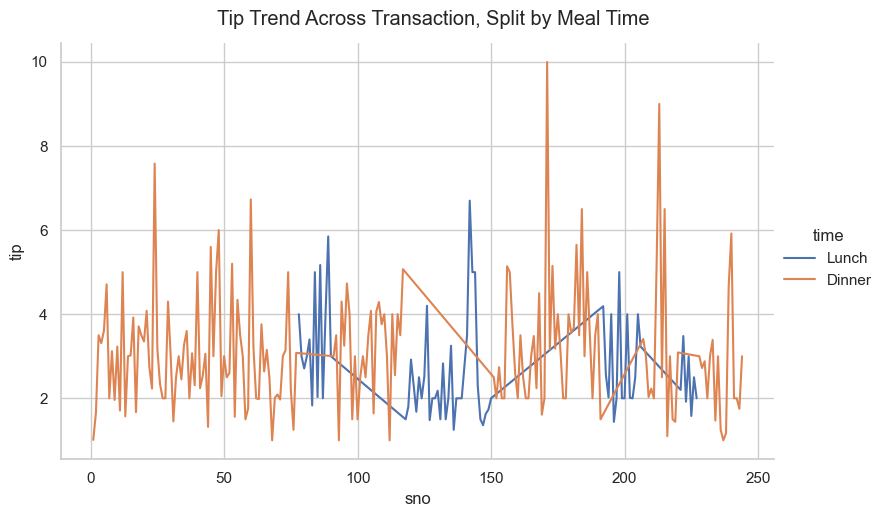

In [27]:
sns.relplot(data=df_sorted, x='sno', y='tip', kind='line', hue='time',
            height=5, aspect=1.6)
plt.suptitle('Tip Trend Across Transaction, Split by Meal Time', y=1.03)
plt.show()

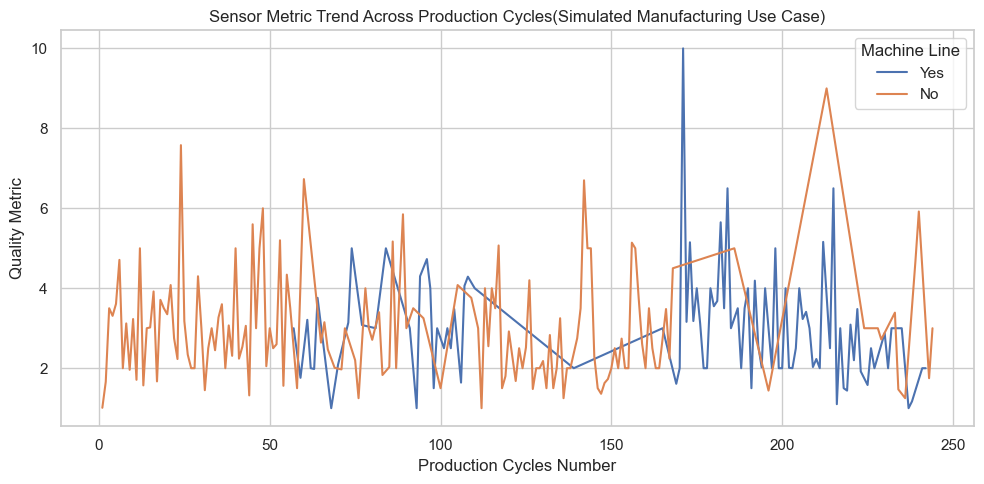

In [28]:

plt.figure(figsize=(10,5))
sns.lineplot(x ='sno', y='tip', data=df_sorted, hue='smoker',
estimator='mean', errorbar=('ci',95))                
plt.title('Sensor Metric Trend Across Production Cycles(Simulated Manufacturing Use Case)')
plt.xlabel('Production Cycles Number')
plt.ylabel('Quality Metric')
plt.legend(title='Machine Line')
plt.grid(True)
plt.tight_layout()
plt.show()

## 10 Joint Plot - sns.jointplot()

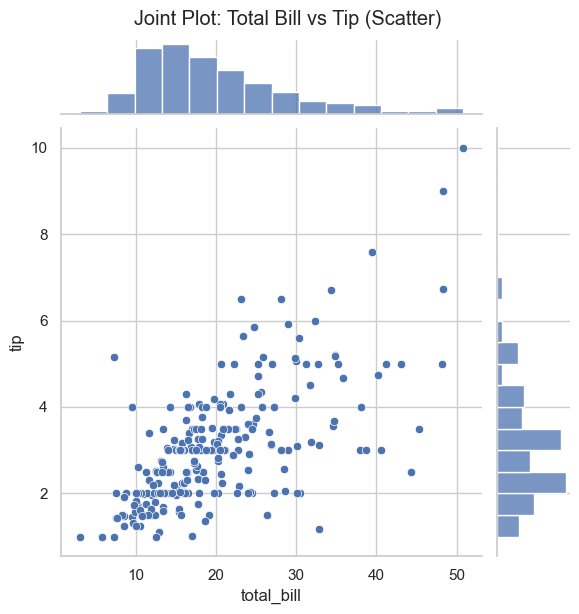

In [29]:
sns.jointplot(data=df, x='total_bill', y='tip', height=6)
plt.suptitle('Joint Plot: Total Bill vs Tip (Scatter)', y=1.02)
plt.show()

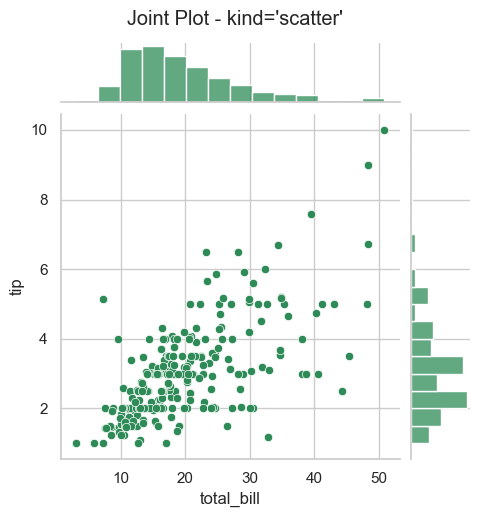

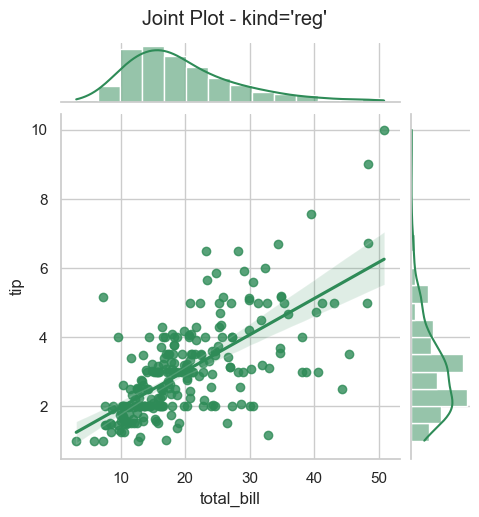

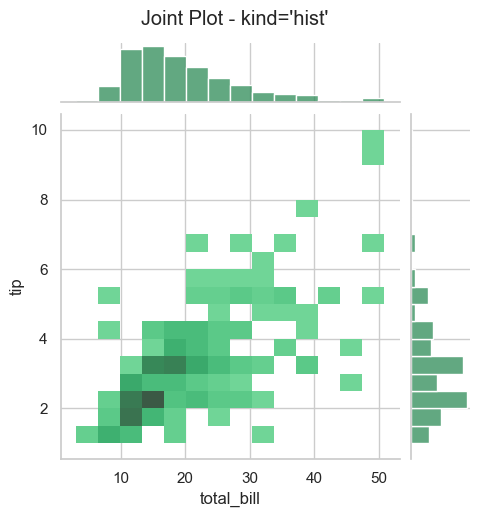

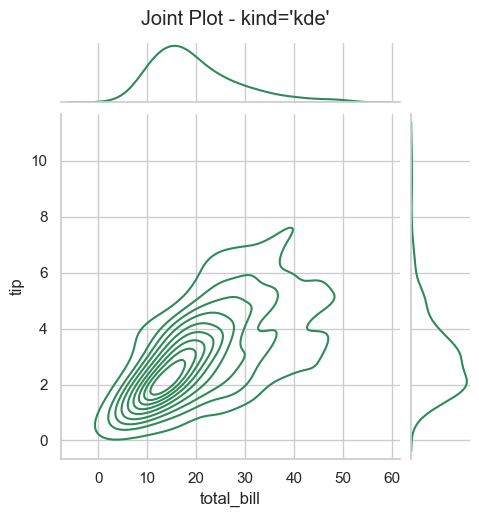

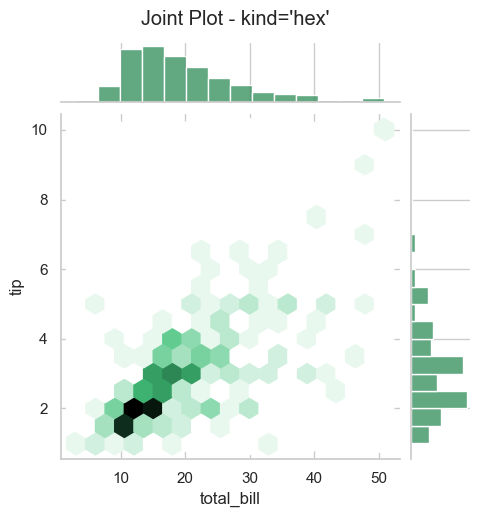

In [30]:
fig_kinds = ['scatter', 'reg', 'hist', 'kde', 'hex']
for k in fig_kinds:
    g = sns.jointplot(data=df, x='total_bill', y='tip', kind=k, height=5,
color='seagreen')
    g.fig.suptitle(f"Joint Plot - kind='{k}' ", y=1.03)
    plt.show()

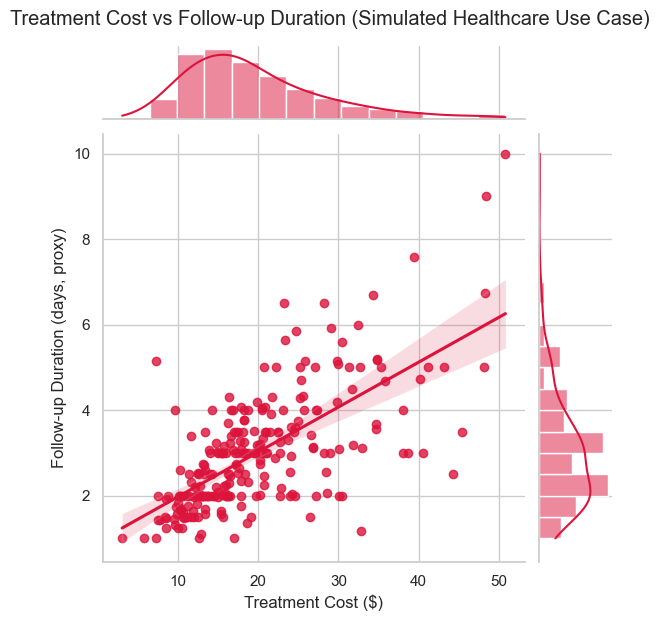

In [31]:
g = sns.jointplot(data=df, x='total_bill', y='tip', kind='reg', height=6,
                  color='crimson')
g.fig.suptitle('Treatment Cost vs Follow-up Duration (Simulated Healthcare Use Case)', y=1.03)
g.ax_joint.set_xlabel('Treatment Cost ($)')
g.ax_joint.set_ylabel('Follow-up Duration (days, proxy)')
plt.show()

## 11 Violin Plot - sns.violinplot()

C:\Users\User\AppData\Local\Temp\ipykernel_20040\2858226074.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='total_bill', y='day', data=df, palette='muted')


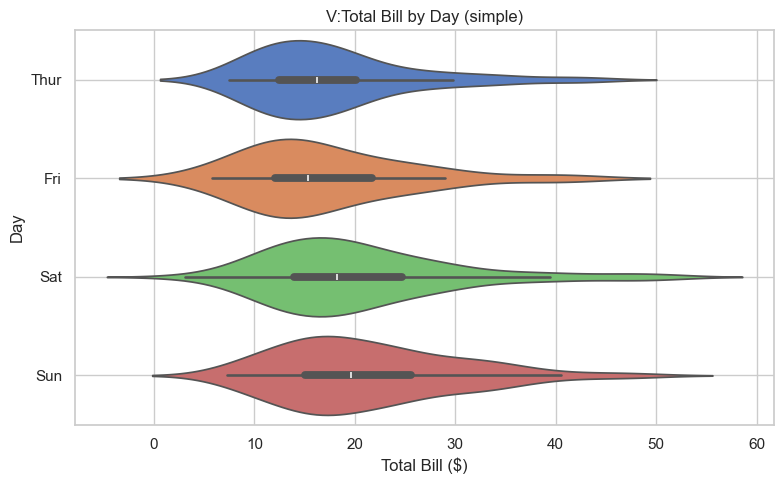

In [32]:
plt.figure(figsize=(8,5))
sns.violinplot(x='total_bill', y='day', data=df, palette='muted')
plt.title('V:Total Bill by Day (simple)')
plt.xlabel('Total Bill ($)')
plt.ylabel('Day')
plt.grid(True)
plt.tight_layout()
plt.show()

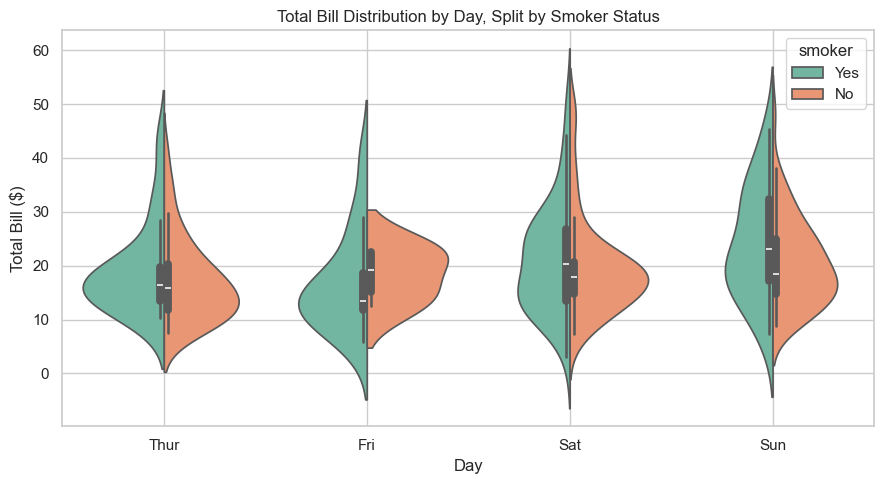

In [33]:
plt.figure(figsize=(9,5))
sns.violinplot(data=df, x='day', y='total_bill', hue='smoker', split=True,
palette='Set2')
plt.title('Total Bill Distribution by Day, Split by Smoker Status')
plt.xlabel('Day')
plt.ylabel('Total Bill ($)')
plt.grid(True)
plt.tight_layout()
plt.show()

# 12. Pair Plot - sns.pairplot()

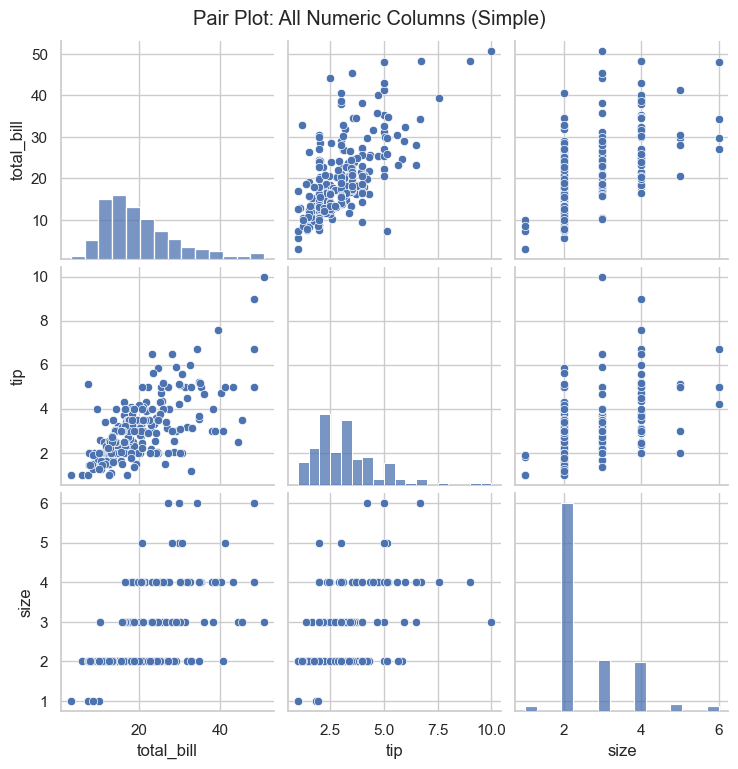

In [34]:
sns.pairplot(df)
plt.suptitle('Pair Plot: All Numeric Columns (Simple)', y=1.02)
plt.show()

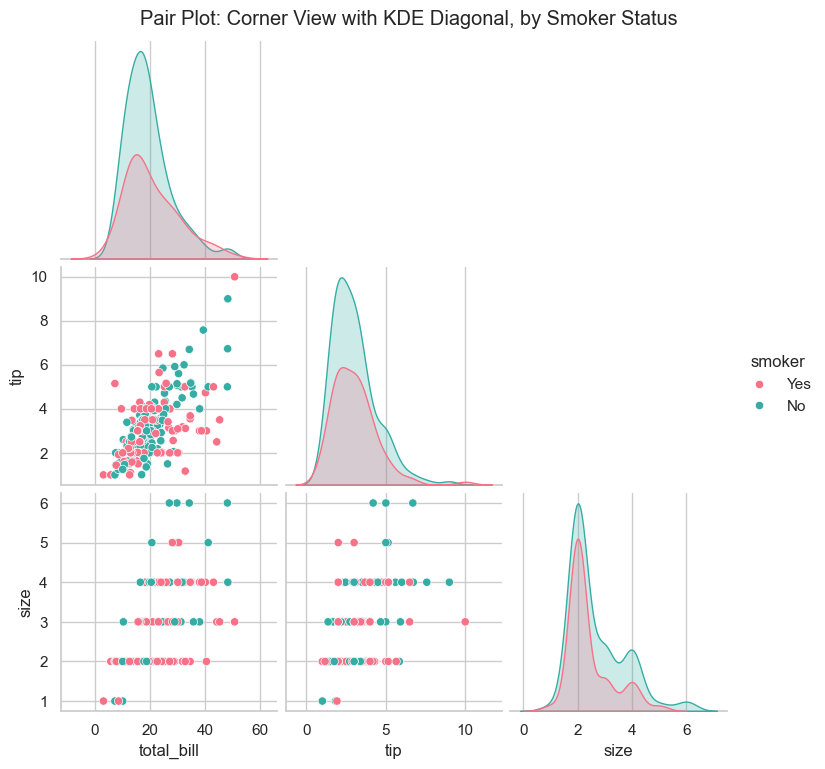

In [35]:
sns.pairplot(df, hue='smoker', corner=True, diag_kind='kde',
palette='husl')
plt.suptitle('Pair Plot: Corner View with KDE Diagonal, by Smoker Status', y=1.02)
plt.show()

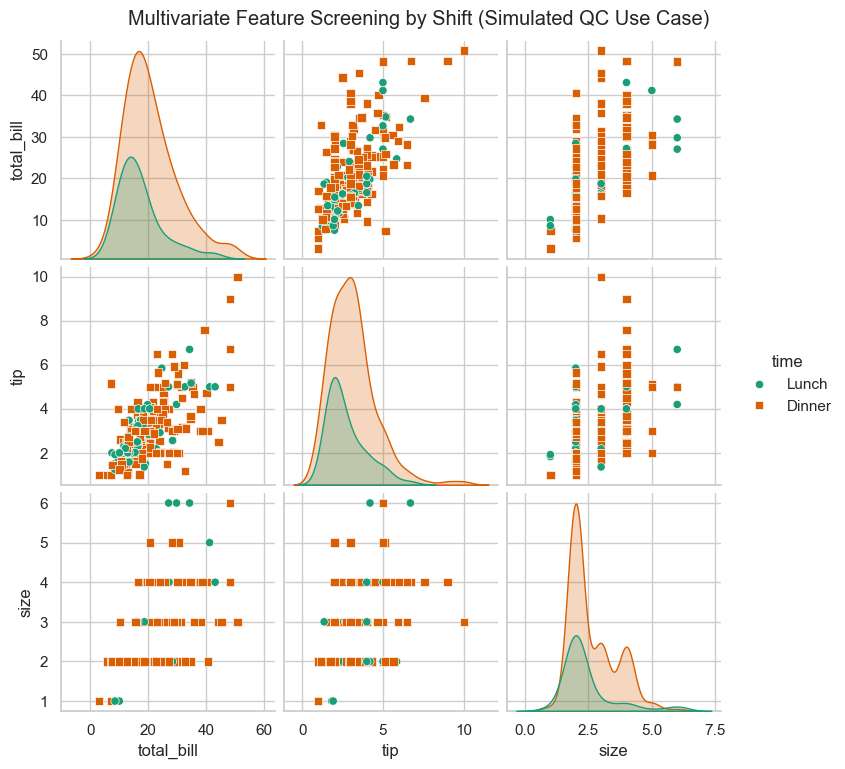

In [36]:
sns.pairplot(df, vars=['total_bill', 'tip', 'size'], hue='time',
             markers=['o', 's'], palette='Dark2', diag_kind='kde',
corner=False)
plt.suptitle('Multivariate Feature Screening by Shift (Simulated QC Use Case)', y=1.02)
plt.show()

# 13. Heatmap - sns.heatmapt()

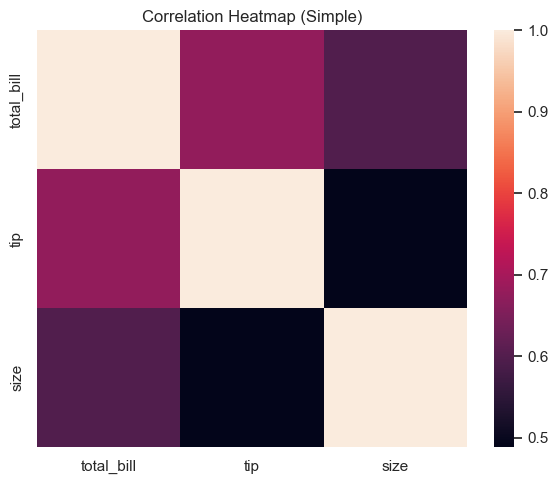

In [37]:
corr= df.corr(numeric_only=True)
plt.figure(figsize=(6,5))
sns.heatmap(corr)
plt.title('Correlation Heatmap (Simple)')
plt.tight_layout()
plt.show()